In [30]:
import os
import matplotlib.pyplot as plt
import nibabel as nib
import numpy as np

FIGURE_FACECOLOR = '#060606' # Black background 

# Font sizes
SMALL_SIZE = 11
MEDIUM_SIZE = 13
BIGGER_SIZE = 15

plt.rc('font', size=SMALL_SIZE, family='sans-serif')
plt.rc('axes', titlesize=MEDIUM_SIZE)
plt.rc('axes', labelsize=MEDIUM_SIZE)
plt.rc('xtick', labelsize=SMALL_SIZE)
plt.rc('ytick', labelsize=SMALL_SIZE)
plt.rc('legend', fontsize=SMALL_SIZE)
plt.rc('figure', titlesize=BIGGER_SIZE, facecolor=FIGURE_FACECOLOR) # Apply facecolor default

# White text and axes
plt.rc('text', color='white')
plt.rc('axes', labelcolor='white', edgecolor='white', titlecolor='white')
plt.rc('xtick', color='white')
plt.rc('ytick', color='white')
plt.rc('figure', edgecolor=FIGURE_FACECOLOR)

PROB_CMAP = 'hot'

def save_figure(fig, filename_base):
    """Saves the figure in PDF and PNG formats."""
    pdf_path = f"{filename_base}.pdf"
    png_path = f"{filename_base}.png"
    os.makedirs(os.path.dirname(filename_base), exist_ok=True)
    try:
        fig.savefig(pdf_path, bbox_inches='tight', facecolor=fig.get_facecolor(), edgecolor='none', format='pdf')
        fig.savefig(png_path, bbox_inches='tight', facecolor=fig.get_facecolor(), edgecolor='none', dpi=300, format='png')
        print(f"Saved {pdf_path} and {png_path}")
    except Exception as e:
        print(f"Error saving figure {filename_base}: {e}")

print("Setup for Figure 1 complete.")

Setup for Figure 1 complete.


### Data loading

In [31]:
subject_path = os.path.expanduser('~/Code/datasets/wmh_bck/training/Utrecht/0')
output_dir = os.path.join("notebooks/main/figs/pdfs")
figure_basename = os.path.join(output_dir, "Figure1")

# Assumes runs_to_compare is defined globally or loaded previously
# Example definition if needed:
runs_to_compare = {
    'CE UtAmSi': 'training_Utrecht_Amsterdam_Singapore_CE_3684_best',
    'CE_MEEP UtAmSi': 'training_Utrecht_Amsterdam_Singapore_MEEP_6996_best',
}
train_center_key = 'UtAmSi'

# Get run names needed for this figure
run_name_ce = runs_to_compare.get(f'CE {train_center_key}')
run_name_ce_meep = runs_to_compare.get(f'CE_MEEP {train_center_key}')


print(f"Loading data for subject: {subject_path}")
imgs = {}
affine = None # Store affine for consistent orientation if needed
header = None # Store header

# Load FLAIR
flair_path = os.path.join(subject_path, 'pre/FLAIR.nii.gz')
if os.path.exists(flair_path):
    try:
        flair_img = nib.load(flair_path)
        imgs['FLAIR'] = flair_img.get_fdata()
        affine = flair_img.affine
        header = flair_img.header
        print(f"Loaded FLAIR: {imgs['FLAIR'].shape}")
    except Exception as e:
        print(f"Error loading FLAIR {flair_path}: {e}")
        # Handle error appropriately, e.g., skip subject or exit
else:
    print(f"Error: FLAIR not found at {flair_path}")
    # Handle error appropriately

# Load CE Softmax Prediction
if run_name_ce:
    pred_ce_path = os.path.join(subject_path, f'pred_wmh_softmax_{run_name_ce}.nii.gz')
    if os.path.exists(pred_ce_path):
        try:
            pred_ce_softmax = nib.load(pred_ce_path).get_fdata()
            # Assuming shape is (Z, Y, X, C) or (X, Y, Z, C) and channel 1 is WMH prob
            if pred_ce_softmax.shape[-1] == 2:
                 imgs['CE_Prob'] = pred_ce_softmax[..., 1]
                 print(f"Loaded CE Prediction: {imgs['CE_Prob'].shape}")
            else:
                 print(f"Warning: CE Prediction at {pred_ce_path} has unexpected channel dimension: {pred_ce_softmax.shape}. Skipping.")
        except Exception as e:
            print(f"Error loading CE Prediction {pred_ce_path}: {e}")
    else:
        print(f"Warning: CE Prediction not found: {pred_ce_path}")
else:
    print("Warning: Run name for CE not found.")


# Load CE+MEEP Softmax Prediction
if run_name_ce_meep:
    pred_ce_meep_path = os.path.join(subject_path, f'pred_wmh_softmax_{run_name_ce_meep}.nii.gz')
    if os.path.exists(pred_ce_meep_path):
        try:
            pred_ce_meep_softmax = nib.load(pred_ce_meep_path).get_fdata()
            if pred_ce_meep_softmax.shape[-1] == 2:
                 imgs['CE_MEEP_Prob'] = pred_ce_meep_softmax[..., 1]
                 print(f"Loaded CE+MEEP Prediction: {imgs['CE_MEEP_Prob'].shape}")
            else:
                 print(f"Warning: CE+MEEP Prediction at {pred_ce_meep_path} has unexpected channel dimension: {pred_ce_meep_softmax.shape}. Skipping.")
        except Exception as e:
            print(f"Error loading CE+MEEP Prediction {pred_ce_meep_path}: {e}")
    else:
        print(f"Warning: CE+MEEP Prediction not found: {pred_ce_meep_path}")
else:
    print("Warning: Run name for CE_MEEP not found.")

print("Data loading for Figure 1 complete.")

# --- Compute voxel spacing for aspect ratio correction ---
if header is not None:
    voxel_spacing = header.get_zooms()[:3]  # (dx, dy, dz)
    dx, dy, dz = voxel_spacing
    aspect_axial = dy / dx if dx > 0 else 1.0
    aspect_sagittal = dz / dy if dy > 0 else 1.0
    print(f"Voxel spacing: dx={dx}, dy={dy}, dz={dz}")
    print(f"Axial aspect: {aspect_axial}, Sagittal aspect: {aspect_sagittal}")
else:
    aspect_axial = 1.0
    aspect_sagittal = 1.0

Loading data for subject: /home/appuser/Code/datasets/wmh_bck/training/Utrecht/0
Loaded FLAIR: (240, 240, 48)
Loaded CE Prediction: (240, 240, 48)
Loaded CE+MEEP Prediction: (240, 240, 48)
Data loading for Figure 1 complete.
Voxel spacing: dx=0.9583333134651184, dy=0.9583332538604736, dz=2.9999992847442627
Axial aspect: 0.9999999403953552, Sagittal aspect: 3.130434274673462


### Plot figure

In [32]:
# --- Default Parameter Dictionaries ---

DEFAULT_SLICE_PARAMS = {
    'slice_x': 100,
    'slice_y': 100,
    'slice_z': 50,
}

DEFAULT_FIG_PARAMS = {
    'width': 11,
    'height': 7.5,
    'facecolor': FIGURE_FACECOLOR,
}

DEFAULT_LAYOUT_PARAMS = {
    'n_rows': 2,
    'n_cols': 3,
    'margins': {
        'left': 0.05,
        'right': 0.88,
        'bottom': 0.1,
        'top': 0.95,
    },
    'spacing': {
        'hspace': 0.03,
        'wspace': -0.01,
    }
}

DEFAULT_PLOT_CONFIG = {
    'keys': ['FLAIR', 'CE_Prob', 'CE_MEEP_Prob'],
    'titles': ['FLAIR', 'CE Softmax', 'CE+MEEP Softmax'],
}

# --- Main Function ---

def plot_multi_view_image_grid(imgs,
                                slice_params=DEFAULT_SLICE_PARAMS,
                                fig_params=DEFAULT_FIG_PARAMS,
                                layout_params=DEFAULT_LAYOUT_PARAMS,
                                plot_config=DEFAULT_PLOT_CONFIG):

    img_data = imgs['FLAIR']
    slice_x = slice_params['slice_x']
    slice_z = slice_params['slice_z']

    # Create Figure
    fig = plt.figure(figsize=(fig_params['width'], fig_params['height']))
    fig.set_facecolor(fig_params['facecolor'])

    # Layout calculations
    n_rows = layout_params['n_rows']
    n_cols = layout_params['n_cols']
    margins = layout_params['margins']
    spacing = layout_params['spacing']

    plot_area_width = margins['right'] - margins['left']
    plot_area_height = margins['top'] - margins['bottom']
    ax_width = (plot_area_width - (n_cols - 1) * spacing['wspace']) / n_cols
    ax_height = (plot_area_height - (n_rows - 1) * spacing['hspace']) / n_rows

    axs = [[None for _ in range(n_cols)] for _ in range(n_rows)]
    for r in range(n_rows):
        for c in range(n_cols):
            ax_left = margins['left'] + c * (ax_width + spacing['wspace'])
            ax_bottom = margins['top'] - (r + 1) * ax_height - r * spacing['hspace']
            axs[r][c] = fig.add_axes([ax_left, ax_bottom, ax_width, ax_height])

    # Plotting
    im = None
    for col, key in enumerate(plot_config['keys']):
        # Axial
        ax_axial = axs[0][col]
        if key in imgs and imgs[key] is not None and imgs[key].ndim == 3:
            axial = np.rot90(imgs[key][:, :, slice_z])
            if key == 'FLAIR':
                ax_axial.imshow(axial, cmap='gray', aspect=aspect_axial)
            else:
                flair_axial = np.rot90(imgs['FLAIR'][:, :, slice_z])
                ax_axial.imshow(flair_axial, cmap='gray', aspect=aspect_axial)
                im = ax_axial.imshow(axial, cmap=PROB_CMAP, alpha=0.6, vmin=0, vmax=1, aspect=aspect_axial)
        ax_axial.set_title(plot_config['titles'][col])
        ax_axial.axis('off')

        # Sagittal
        ax_sagittal = axs[1][col]
        if key in imgs and imgs[key] is not None and imgs[key].ndim == 3:
            sagittal = np.rot90(imgs[key][slice_x, :, :])
            if key == 'FLAIR':
                ax_sagittal.imshow(sagittal, cmap='gray', aspect=aspect_sagittal)
            else:
                flair_sagittal = np.rot90(imgs['FLAIR'][slice_x, :, :])
                ax_sagittal.imshow(flair_sagittal, cmap='gray', aspect=aspect_sagittal)
                ax_sagittal.imshow(sagittal, cmap=PROB_CMAP, alpha=0.6, vmin=0, vmax=1, aspect=aspect_sagittal)
        else:
            ax_sagittal.text(0.5, 0.5, "Data\nNot Found", ha='center', va='center',
                             transform=ax_sagittal.transAxes, color='gray')
        ax_sagittal.axis('off')

        # Row labels
        if col == 0:
            axs[0][0].text(-0.05, 0.5, 'Axial', rotation=90, va='center', ha='right',
                           transform=axs[0][0].transAxes, fontsize=MEDIUM_SIZE)
            axs[1][0].text(-0.05, 0.5, 'Sagittal', rotation=90, va='center', ha='right',
                           transform=axs[1][0].transAxes, fontsize=MEDIUM_SIZE)

    # Colorbar
    if im is not None:
        cbar_ax = fig.add_axes([
            margins['right'] + 0.015,
            margins['bottom'] + 0.25,
            0.025,
            margins['top'] * 0.45
        ])
        cbar = fig.colorbar(im, cax=cbar_ax)
        cbar.set_label('Softmax Probability', size=MEDIUM_SIZE)
        cbar.ax.tick_params(labelsize=SMALL_SIZE)
        cbar.set_ticks(np.linspace(0, 1, 6))
    else:
        print("Skipping colorbar as no probability maps were plotted.")

    save_figure(fig, figure_basename)
    plt.show()


Saved notebooks/main/figs/pdfs/Figure1.pdf and notebooks/main/figs/pdfs/Figure1.png


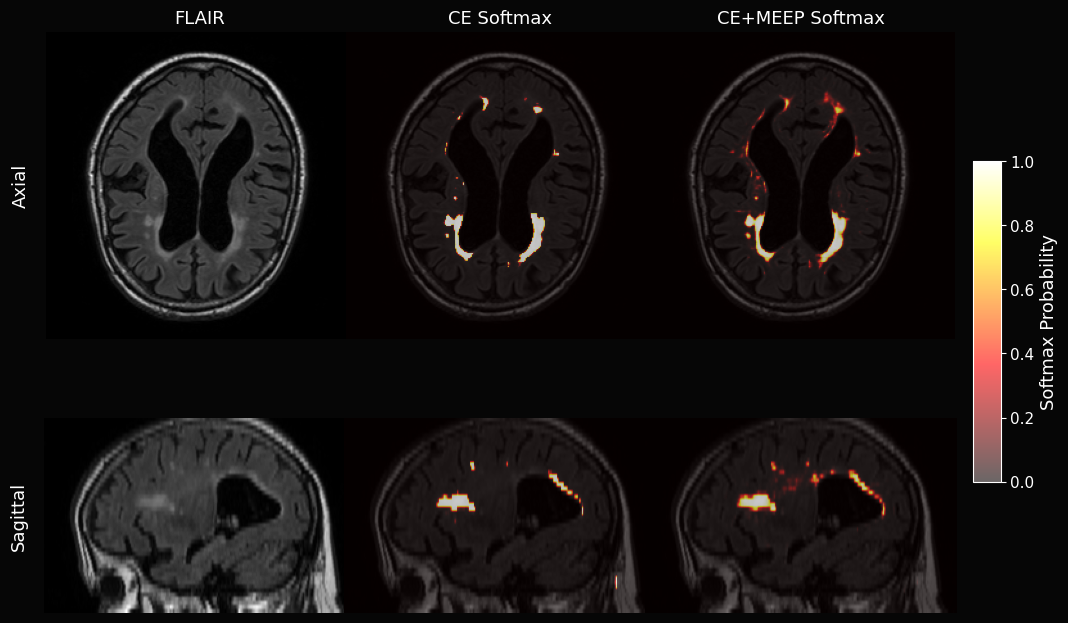

In [33]:
plot_multi_view_image_grid(imgs, slice_params={'slice_x': 152, 'slice_z': 28},)